# 🧪 Module 23 Practice Notebook: K-Means Clustering

This notebook is for **student practice**.

### Objectives
- Practice implementing K-Means step by step
- Understand the role of scaling
- Use Elbow Method to choose k
- Interpret clustering results

**Instructions:**
- Do NOT skip TODOs
- Run cells in order
- Write your code only where TODO is mentioned

---


## 🔹 Section 1: Import Necessary Libraries

**TODO:** Import all required libraries for K-Means clustering.

Hint:
- numpy, pandas
- matplotlib, seaborn
- KMeans, StandardScaler


In [6]:
# TODO: Write your import statements here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from google.colab import files

## 🔹 Section 2: Load the Dataset

We will use a **customer behavior dataset**.

Features:
- Annual Income (k$)
- Spending Score (1–100)


In [9]:
# Dataset source (do not change)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mall_customers.csv"

# TODO: Load the dataset using pandas and store it in df
# upload = files.upload()
df = pd.read_csv('Mall_Customers.csv')



## 🔹 Section 3: Explore the Dataset

**TODO:**
- Display first 5 rows
- Check dataset shape
- Check column names


In [25]:
# df.head(5)
# display(df.shape)
display(df.columns)
# df.describe()

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

## 🔹 Section 4: Select Features for Clustering

We will use only numeric features:
- Annual Income (k$)
- Spending Score (1-100)

**TODO:** Create feature matrix X.


In [26]:
# TODO: Select the two features and store in X
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 🔹 Section 5: Feature Scaling

K-Means uses distance.

**TODO:**
- Create a StandardScaler
- Fit and transform X
- Store scaled data in X_scaled


In [27]:
# TODO: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 🔹 Section 6: Elbow Method (Choosing k)

**TODO:**
- Run K-Means for k = 1 to 10
- Store inertia values
- Plot k vs inertia


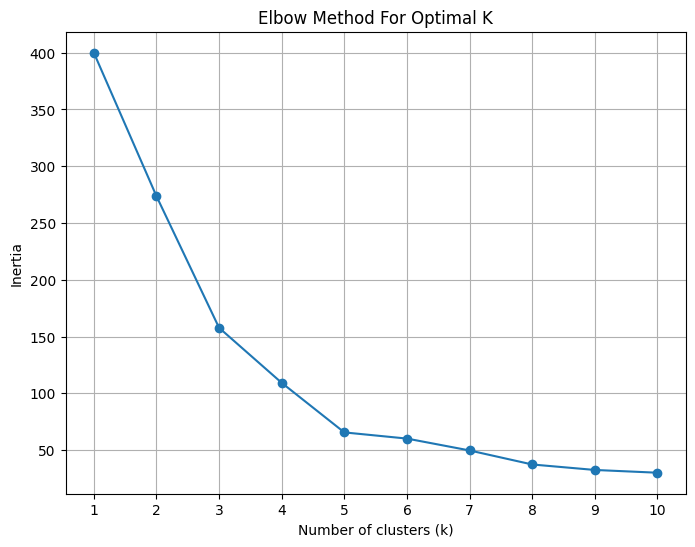

In [33]:
# TODO: Implement the Elbow Method
k_range = range(1,11)

inertia=[]

for k in k_range:
  km = KMeans(n_clusters=k, random_state=42,max_iter=200, n_init='auto')
  km.fit(X_scaled)
  inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)


## 🔹 Section 7: Apply K-Means Clustering

Choose k based on the Elbow plot.

**TODO:**
- Create KMeans model
- Fit on X_scaled
- Get cluster labels


In [29]:
# TODO: Fit K-Means and get labels
kmeans = KMeans(n_clusters=5, random_state=42,max_iter=200, n_init='auto')
kmeans.fit(X_scaled)
labels = kmeans.labels_
labels[:50]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0], dtype=int32)

## 🔹 Section 8: Visualize the Clusters

**TODO:**
- Add cluster labels to dataframe
- Create a scatter plot
- Color points by cluster


In [30]:
# TODO: Visualize the clusters
df['Cluster'] = labels
df.head(5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 🔹 Section 9: Evaluate Clustering (Silhouette Score)

**TODO:**
- Calculate silhouette score
- Print the score
- Comment on the quality


In [32]:
# TODO: Compute silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score}")




Silhouette Score: 0.5546571631111091


## 🔹 Section 10: Reflection Questions

Answer in markdown (write below):

1. Why is scaling mandatory for K-Means?
2. What happens if k is chosen too large?
3. Is K-Means suitable for all datasets? Why or why not?


_Write your answers here._


# Task
Complete the elbow method visualization by calculating the inertia for k values from 1 to 10, and then plotting k versus inertia.

## Calculate Inertia for different k values

### Subtask:
Iterate from k=1 to k=10, run KMeans on X_scaled for each k, and store the inertia values in a list.


**Reasoning**:
The subtask requires calculating the inertia for K-Means models with varying numbers of clusters (k from 1 to 10) to prepare for the Elbow Method. This involves initializing a list, looping through k values, fitting KMeans, and storing the inertia.



In [22]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto') # Added n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

**Reasoning**:
The inertia values have been calculated for different k values. The next step is to visualize these values using a line plot to identify the 'elbow' point, which helps in choosing the optimal number of clusters (k).



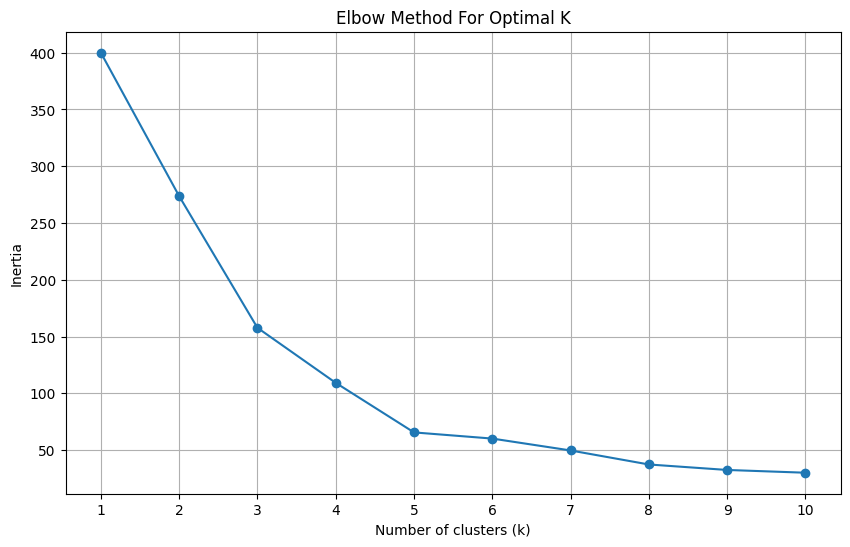

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()